In [7]:
from google.colab import files
uploaded = files.upload()


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
cleveland = pd.read_csv("Cleavland.csv", header=None)
hungary = pd.read_csv("hung.csv", header=None)
switzerland = pd.read_csv("Switzerland.csv", header=None)

# Assign column names
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

cleveland.columns = cols
hungary.columns = cols
switzerland.columns = cols

# Merge
df = pd.concat([cleveland, hungary, switzerland], ignore_index=True)

# Clean
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

# Convert target to binary
#df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Merged Shape:", df.shape)

Saving Switzerland.csv to Switzerland (1).csv
Saving hung.csv to hung (1).csv
Saving Cleavland.csv to Cleavland (1).csv
Merged Shape: (298, 14)


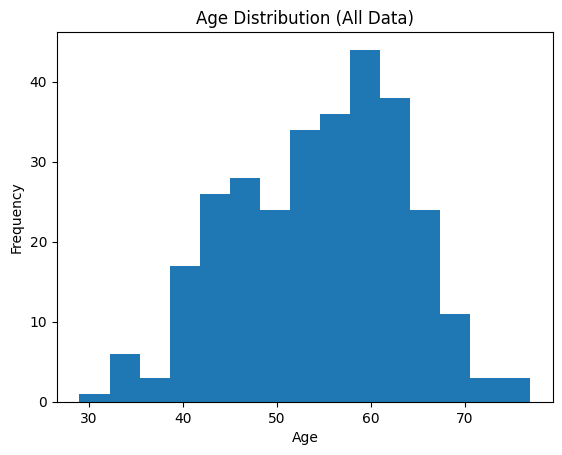

In [8]:
plt.figure()
plt.hist(df['age'], bins=15)
plt.title("Age Distribution (All Data)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

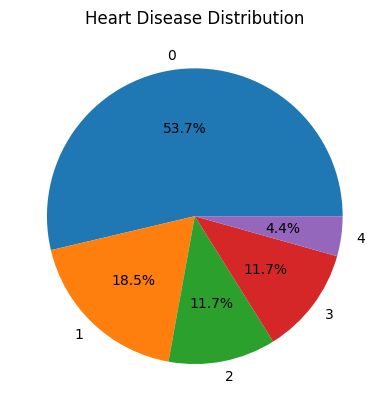

In [11]:
#counts = df['target'].value_counts()

#plt.figure()
#plt.pie(counts, labels=['No Disease','Disease'], autopct='%1.1f%%')
#plt.title("Heart Disease Proportion")
#plt.show()


# Count disease classes
disease_count = df['target'].value_counts()

# Pie Chart
plt.figure()

plt.pie(disease_count.values,labels=disease_count.index,autopct='%1.1f%%')

plt.title("Heart Disease Distribution")

plt.show()

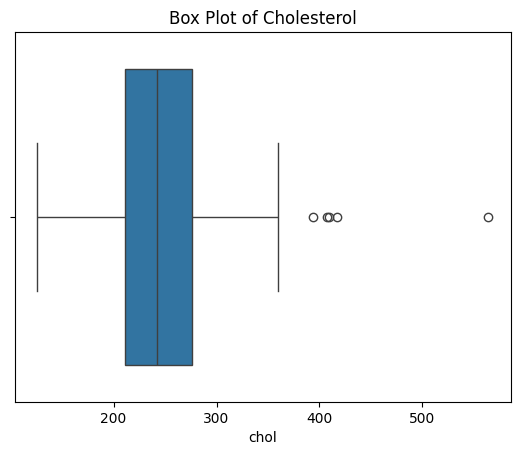

In [14]:
plt.figure()
sns.boxplot(x=df['chol'])
plt.title("Box Plot of Cholesterol")
plt.show()

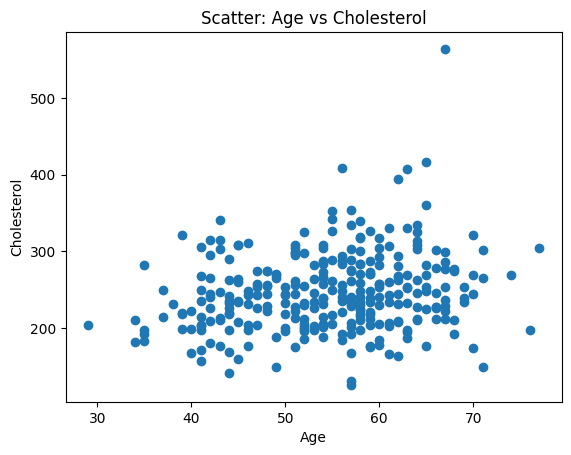

In [15]:
plt.figure()
plt.scatter(df['age'], df['chol'])
plt.title("Scatter: Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

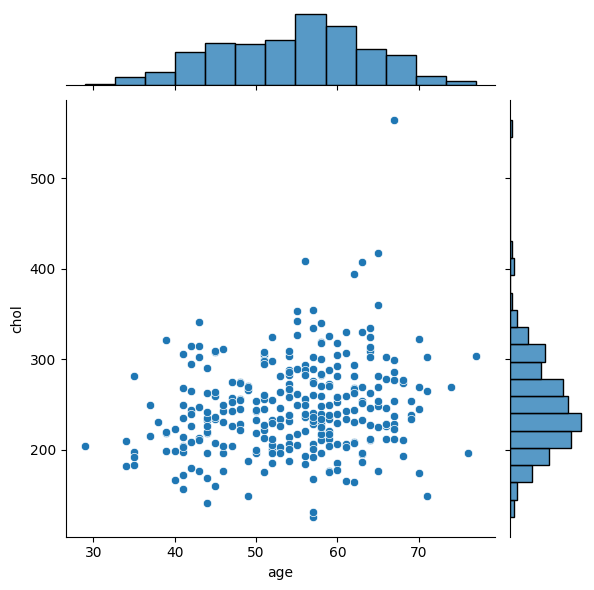

In [18]:
sns.jointplot(x='age',y='chol',data=df,kind='scatter')

plt.show()
